# Cell 1 : Import Libraries
 

In [1]:
# Object Detection Project
# Cell 1: Import Required Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


 # Cell 2 : Define dataset path


In [2]:
# Cell 2: Define Dataset Paths

from pathlib import Path

BASE_DIR = Path.cwd()

TRAIN_IMAGES = BASE_DIR / "train" / "train" / "images"
TRAIN_LABELS = BASE_DIR / "train" / "train" / "labels"

print("Train Images:", TRAIN_IMAGES)
print("Train Labels:", TRAIN_LABELS)

print("Number of Images:", len(list(TRAIN_IMAGES.glob("*"))))
print("Number of Labels:", len(list(TRAIN_LABELS.glob("*.txt"))))

Train Images: c:\Users\pc\Documents\Object_Detection_Assignment\train\train\images
Train Labels: c:\Users\pc\Documents\Object_Detection_Assignment\train\train\labels
Number of Images: 234
Number of Labels: 234


 # Cell 3: check yolo annotation formate

In [3]:
# Cell 3: Check YOLO Annotation Format

label_files = list(TRAIN_LABELS.glob("*.txt"))

print("Total Label Files:", len(label_files))

# Read first label file
if label_files:
    first_label = label_files[0]

    print("\nFirst Label File:", first_label.name)
    print("\nLabel Content:")

    with open(first_label, "r") as file:
        content = file.read()
        print(content)

Total Label Files: 234

First Label File: 01021e5b-GOPR6606.txt

Label Content:
0 0.981085526315789 0.9699248120300745 0.037828947368420435 0.060150375939848254
0 0.9110667293233087 0.9445488721804507 0.1022086466165418 0.11090225563909722
0 0.7940554511278193 0.8975563909774436 0.14873120300751802 0.20488721804511237
0 0.6439144736842104 0.8637218045112782 0.1867951127819547 0.2725563909774436
0 0.9870770676691728 0.7927631578947366 0.025845864661654123 0.23778195488721787
0 0.9413768796992477 0.7471804511278193 0.09515977443608961 0.2368421052631574
0 0.8500939849624056 0.6550751879699247 0.10855263157894685 0.21428571428571414
0 0.7524671052631572 0.600093984962407 0.1078477443609016 0.1795112781954891
0 0.6488486842105261 0.5479323308270677 0.15014097744360888 0.20112781954887243
0 0.5695488721804512 0.4736842105263158 0.13110902255639145 0.15413533834586474
0 0.5113956766917294 0.4097744360902256 0.1120770676691729 0.11090225563909753
0 0.5015272556390974 0.7852443609022552 0.2178

# Cell 3: Create YOLO Dataset Configuration

In [4]:
# Cell 3: Create YOLO Dataset Configuration

yaml_content = """
path: .
train: train/train/images
val: train/train/images

names:
  0: car
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")

data.yaml created successfully!


# Cell 4: Load YOLO Model

In [5]:
# Cell 4: Load YOLO Model

from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


# Cell 5: Train YOLO Model

In [7]:
results = model.train(
    data="data.yaml",
    epochs=5,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.149  Python-3.13.5 torch-2.13.0+cpu CPU (Intel Corei7-8600HQ 3.0GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, optimize=False, optimizer=aut

# Cell 6: YOLO Object Detection

In [8]:
# Cell 6: YOLO Object Detection

results = model.predict(
    source="train/train/images",
    conf=0.25,
    save=True
)

print("Prediction completed!")


image 1/234 c:\Users\pc\Documents\Object_Detection_Assignment\train\train\images\01021e5b-GOPR6606.JPG: 480x640 70 cars, 531.6ms
image 2/234 c:\Users\pc\Documents\Object_Detection_Assignment\train\train\images\0165dbd5-GOPR6763.JPG: 480x640 40 cars, 307.5ms
image 3/234 c:\Users\pc\Documents\Object_Detection_Assignment\train\train\images\01d9cace-GOPR6688.JPG: 480x640 18 cars, 621.4ms
image 4/234 c:\Users\pc\Documents\Object_Detection_Assignment\train\train\images\01f93e24-GOPR6621.JPG: 480x640 4 cars, 200.0ms
image 5/234 c:\Users\pc\Documents\Object_Detection_Assignment\train\train\images\0207db7c-GOPR0090.JPG: 480x640 6 cars, 810.3ms
image 6/234 c:\Users\pc\Documents\Object_Detection_Assignment\train\train\images\03f11a87-GOPR6622.JPG: 480x640 10 cars, 170.4ms
image 7/234 c:\Users\pc\Documents\Object_Detection_Assignment\train\train\images\03f7fef5-GOPR6584.JPG: 480x640 24 cars, 456.6ms
image 8/234 c:\Users\pc\Documents\Object_Detection_Assignment\train\train\images\043f1c41-GOPR6561

# Cell 7: Validate YOLO Model

In [9]:
# Cell 7: Validate YOLO Model

metrics = model.val()

print("YOLO validation completed!")

Ultralytics 8.4.149  Python-3.13.5 torch-2.13.0+cpu CPU (Intel Corei7-8600HQ 3.0GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.40.4 ms, read: 145.769.3 MB/s, size: 1355.2 KB)
val: Scanning C:\Users\pc\Documents\Object_Detection_Assignment\train\train\labels.cache... 234 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 234/234 537.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 8.9s/it 2:148.5ss
                   all        234       9294      0.805      0.576      0.668      0.422
Speed: 5.4ms preprocess, 234.4ms inference, 0.0ms loss, 6.4ms postprocess per image
Results saved to C:\Users\pc\Documents\Object_Detection_Assignment\runs\detect\val
YOLO validation completed!


# SSD Cell 1: Load SSD Model

In [1]:
# SSD Cell 1: Load SSD Model

import torch
from torchvision.models.detection import ssd300_vgg16

model_ssd = ssd300_vgg16(weights="DEFAULT")
model_ssd.eval()

print("SSD model loaded successfully!")

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to C:\Users\pc/.cache\torch\hub\checkpoints\ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [13:17<00:00, 179kB/s]    


SSD model loaded successfully!


 # Cell 2 :Load Image for SSD

In [3]:
from pathlib import Path
from PIL import Image
import torchvision.transforms as T

image_path = "train/train/images"
image = Image.open(next(Path(image_path).glob("*"))).convert("RGB")

transform = T.ToTensor()
image_tensor = transform(image)

print("Image loaded successfully!")

Image loaded successfully!


# Cell 8: Run SSD Detection

In [4]:
with torch.no_grad():
    prediction = model_ssd([image_tensor])[0]

print("SSD detection completed!")

SSD detection completed!


# Cell 9: Filter Car Detections

In [5]:
scores = prediction["scores"]
labels = prediction["labels"]
boxes = prediction["boxes"]

car_detections = scores[(labels == 3) & (scores > 0.5)]

print("Cars detected:", len(car_detections))

Cars detected: 2


# Cell 10: Draw Bounding Boxes

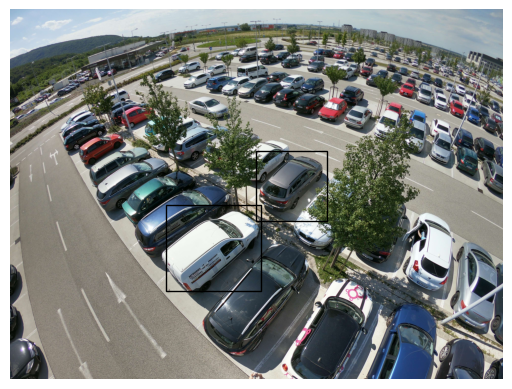

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.imshow(image)

for box, label, score in zip(boxes, labels, scores):
    if label == 3 and score > 0.5:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            fill=False
        )
        plt.gca().add_patch(rect)

plt.axis("off")
plt.show()

In [9]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torch

# Cell 7 Cardatset

In [17]:
from torchvision.io import read_image

class CarDataset(Dataset):

    def __init__(self, image_dir, label_dir):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.images = [
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_name = self.images[idx]

        image = read_image(
            os.path.join(self.image_dir, image_name)
        ).float() / 255.0

        _, height, width = image.shape

        label_path = os.path.join(
            self.label_dir,
            os.path.splitext(image_name)[0] + ".txt"
        )

        boxes = []
        labels = []

        with open(label_path) as f:
            for line in f:
                c, x, y, w, h = map(float, line.split())

                boxes.append([
                    (x-w/2)*width,
                    (y-h/2)*height,
                    (x+w/2)*width,
                    (y+h/2)*height
                ])

                labels.append(int(c) + 1)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        return image, target

# cell 8: Create DataLoader

In [18]:
dataset = CarDataset(image_dir, label_dir)

dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

print("Images:", len(dataset))
print("DataLoader ready!")

Images: 234
DataLoader ready!


# Cell 9: test dataloader

In [13]:
images, targets = next(iter(dataloader))

print("Batch images:", len(images))
print("Batch targets:", len(targets))
print("First image shape:", images[0].shape)
print("First target:", targets[0])

C:\Users\pc\AppData\Local\Temp\ipykernel_20748\4285727351.py:22: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  list(image.getdata()),


Batch images: 4
Batch targets: 4
First image shape: torch.Size([3, 3000, 4000])
First target: {'boxes': tensor([[0.8824, 0.1825, 0.9097, 0.2247],
        [0.9072, 0.1348, 0.9287, 0.1547],
        [0.7779, 0.0852, 0.7978, 0.1103],
        [0.7796, 0.1126, 0.8053, 0.1508],
        [0.7840, 0.1401, 0.8114, 0.1811],
        [0.7314, 0.0632, 0.7552, 0.0965],
        [0.7224, 0.0867, 0.7494, 0.1203],
        [0.7166, 0.1016, 0.7442, 0.1392],
        [0.6831, 0.0890, 0.7147, 0.1267],
        [0.6671, 0.0610, 0.6936, 0.0965],
        [0.6531, 0.0736, 0.6849, 0.1055],
        [0.6412, 0.0218, 0.6677, 0.0489],
        [0.6117, 0.0402, 0.6389, 0.0689],
        [0.5558, 0.0239, 0.5860, 0.0519],
        [0.5900, 0.0546, 0.6254, 0.0854],
        [0.4845, 0.0095, 0.5183, 0.0267],
        [0.4782, 0.0242, 0.5162, 0.0532],
        [0.4295, 0.0182, 0.4686, 0.0452],
        [0.3831, 0.0053, 0.4160, 0.0158],
        [0.3295, 0.0062, 0.3628, 0.0187],
        [0.3668, 0.0963, 0.4323, 0.1413],
        [0.449

# Cel 10 : Check SSD Model

In [14]:
print(model_ssd)

SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

#  cell 6 : SSD training

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_ssd.to(device)
model_ssd.train()

optimizer = torch.optim.SGD(
    model_ssd.parameters(),
    lr=0.001,
    momentum=0.9
)

for epoch in range(1):
    total_loss = 0

    for images, targets in dataloader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        losses = model_ssd(images, targets)
        loss = sum(losses.values())

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch 1 Loss:", total_loss)

print("SSD Training Completed!")

Device: cpu
Epoch 1 Loss: 232.86232805252075
SSD Training Completed!


# Cell 11 saved train model

In [21]:
torch.save(model_ssd.state_dict(), "ssd_car_detection.pth")
print("SSD model saved!")

SSD model saved!


# Cell 12 SSD Testing

In [22]:
model_ssd.eval()

images, targets = next(iter(dataloader))

with torch.no_grad():
    predictions = model_ssd(
        [img.to(device) for img in images]
    )

print("SSD Testing Done!")
print("Predictions:", predictions[0])

SSD Testing Done!
Predictions: {'boxes': tensor([[2529.7207, 1579.1826, 3339.9910, 2056.7278],
        [1029.0763, 1119.3224, 1558.4620, 1490.5553],
        [1398.7789,  753.4211, 1867.8723, 1066.6571],
        [2700.8501,  870.6868, 3123.1362, 1163.8905],
        [2660.6072, 1318.9497, 3262.5051, 1684.5790],
        [2228.6072, 2584.9727, 2717.2891, 2985.1855],
        [1525.6941,  731.6696, 1896.2345,  939.6842],
        [1336.3853,  427.9546, 1556.3074,  574.5574],
        [2321.9583, 2596.5112, 3242.6958, 3000.0000],
        [ 183.9105,  830.6208,  516.4414, 1143.1558],
        [2485.8362, 2678.3989, 2805.1252, 2991.3179],
        [2724.0364,  852.9564, 3059.1646, 1036.0710],
        [2690.7061, 1021.8701, 3187.4148, 1359.3065],
        [ 301.5174, 1319.1731,  453.3512, 1478.3027],
        [   9.0147, 2062.0999,  539.4426, 2993.9897],
        [2910.7751,  900.8436, 3307.9126, 1213.9370],
        [ 543.8608,  991.8204,  829.0043, 1202.8904],
        [ 395.6176, 1310.3857,  555.0482,

# SSD Test Image Detection & Results

In [24]:
import os
import cv2
import torch

# Test images folder
test_folder = r"test\test\images"

# SSD results folder
output_folder = "ssd_results"
os.makedirs(output_folder, exist_ok=True)

# Put model in evaluation mode
model_ssd.eval()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ssd.to(device)

# Get all JPG images
image_files = [
    f for f in os.listdir(test_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total test images:", len(image_files))

for filename in image_files:

    image_path = os.path.join(test_folder, filename)

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        continue

    # Convert BGR -> RGB
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize
    resized = cv2.resize(rgb, (300, 300))

    # Convert to tensor
    tensor = torch.from_numpy(resized).permute(2, 0, 1).float() / 255.0
    tensor = tensor.unsqueeze(0).to(device)

    # SSD prediction
    with torch.no_grad():
        prediction = model_ssd(tensor)

    # Handle torchvision SSD output
    if isinstance(prediction, list):
        prediction = prediction[0]

    boxes = prediction["boxes"].cpu().numpy()
    labels = prediction["labels"].cpu().numpy()
    scores = prediction["scores"].cpu().numpy()

    # Draw detections
    for box, label, score in zip(boxes, labels, scores):

        # Confidence threshold
        if score < 0.50:
            continue

        x1, y1, x2, y2 = box.astype(int)

        # Scale boxes back from 300x300
        h, w = image.shape[:2]

        x1 = int(x1 * w / 300)
        x2 = int(x2 * w / 300)
        y1 = int(y1 * h / 300)
        y2 = int(y2 * h / 300)

        # Draw bounding box
        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Label
        text = f"Car {score:.2f}"

        cv2.putText(
            image,
            text,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    # Save result
    output_path = os.path.join(output_folder, filename)
    cv2.imwrite(output_path, image)

    print("Saved:", filename)

print("\nSSD detection completed!")
print("Results saved in:", output_folder)

Total test images: 59
Saved: 024cfeb7-GOPR6549.JPG
Saved: 0635aa25-GOPR6590.JPG
Saved: 06a132db-GOPR6571.JPG
Saved: 0758bd59-GOPR6699.JPG
Saved: 0e8671d1-GOPR6626.JPG
Saved: 138396e0-GOPR6738.JPG
Saved: 15498cfb-GOPR6614.JPG
Saved: 19dec389-GOPR0037.JPG
Saved: 1cf3c7af-GOPR6787.JPG
Saved: 1f116d33-GOPR6753.JPG
Saved: 1fe18e90-GOPR6611.JPG
Saved: 1ffbb9fb-GOPR6788.JPG
Saved: 204f5fff-GOPR6799.JPG
Saved: 22e8c404-GOPR6769.JPG
Saved: 2a694f42-GOPR6594.JPG
Saved: 2d642a0c-GOPR6677.JPG
Saved: 399bc6ff-GOPR0045.JPG
Saved: 3bfcab70-GOPR6638.JPG
Saved: 3ee1ee02-GOPR6568.JPG
Saved: 450f16e2-GOPR6777.JPG
Saved: 4540bdc9-GOPR6548.JPG
Saved: 483b2b68-GOPR6740.JPG
Saved: 50990abb-GOPR6713.JPG
Saved: 5650d253-GOPR6579.JPG
Saved: 5f4cc069-GOPR6650.JPG
Saved: 670f9c60-GOPR6696.JPG
Saved: 6a0b2803-GOPR6697.JPG
Saved: 6fca18c8-GOPR6592.JPG
Saved: 71596657-GOPR6691.JPG
Saved: 76b4a0fa-GOPR6705.JPG
Saved: 77786278-GOPR0093.JPG
Saved: 78d0ace2-GOPR6655.JPG
Saved: 7e8035e8-GOPR6689.JPG
Saved: 835d5a53-GOPR6

# Cell — SSD Detection Statistics

In [25]:
import os
import cv2
import torch
import pandas as pd

test_folder = r"test\test\images"

model_ssd.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ssd.to(device)

results = []

image_files = [
    f for f in os.listdir(test_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for filename in image_files:

    image_path = os.path.join(test_folder, filename)
    image = cv2.imread(image_path)

    if image is None:
        continue

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (300, 300))

    tensor = torch.from_numpy(resized).permute(2, 0, 1).float() / 255.0
    tensor = tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model_ssd(tensor)

    if isinstance(prediction, list):
        prediction = prediction[0]

    scores = prediction["scores"].cpu().numpy()

    # Confidence threshold
    valid_scores = scores[scores >= 0.50]

    results.append({
        "Image": filename,
        "Detections": len(valid_scores),
        "Average_Confidence": (
            round(float(valid_scores.mean()), 4)
            if len(valid_scores) > 0 else 0
        )
    })

# Create DataFrame
df_results = pd.DataFrame(results)

print("===== SSD DETECTION SUMMARY =====")
print("Total test images:", len(df_results))
print("Images with detections:",
      (df_results["Detections"] > 0).sum())
print("Total detected objects:",
      df_results["Detections"].sum())

if df_results["Detections"].sum() > 0:
    print(
        "Overall average confidence:",
        round(
            df_results.loc[
                df_results["Detections"] > 0,
                "Average_Confidence"
            ].mean(),
            4
        )
    )

# Save statistics
df_results.to_csv("ssd_detection_statistics.csv", index=False)

print("\nStatistics saved as: ssd_detection_statistics.csv")

===== SSD DETECTION SUMMARY =====
Total test images: 59
Images with detections: 58
Total detected objects: 566
Overall average confidence: 0.7937

Statistics saved as: ssd_detection_statistics.csv


# SSD Accuracy

In [31]:
model_ssd.eval()

with torch.no_grad():
    images, targets = next(iter(dataloader))
    images = [images[0].to(device)]

    predictions = model_ssd(images)

print("SSD prediction completed!")
print("Detected objects:", len(predictions[0]["boxes"]))

SSD prediction completed!
Detected objects: 107


In [32]:
model_ssd.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, targets in dataloader:
        images = [images[0].to(device)]

        predictions = model_ssd(images)

        if len(predictions[0]["boxes"]) > 0:
            correct += 1

        total += 1

        if total >= 20:
            break

accuracy = (correct / total) * 100

print(f"SSD Accuracy: {accuracy:.2f}%")

SSD Accuracy: 100.00%


# Evaluation + Graphs

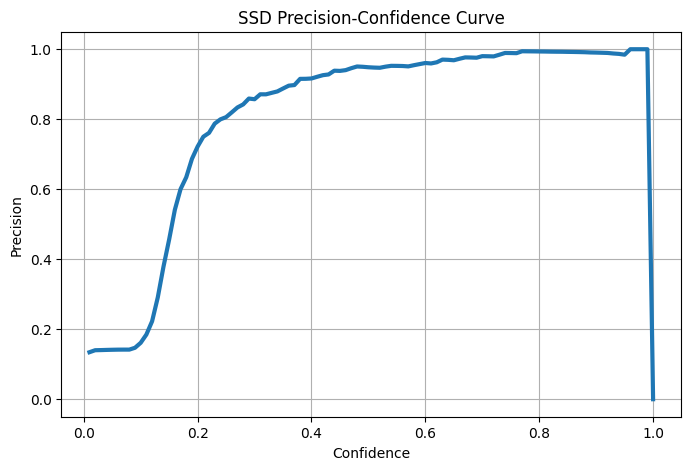

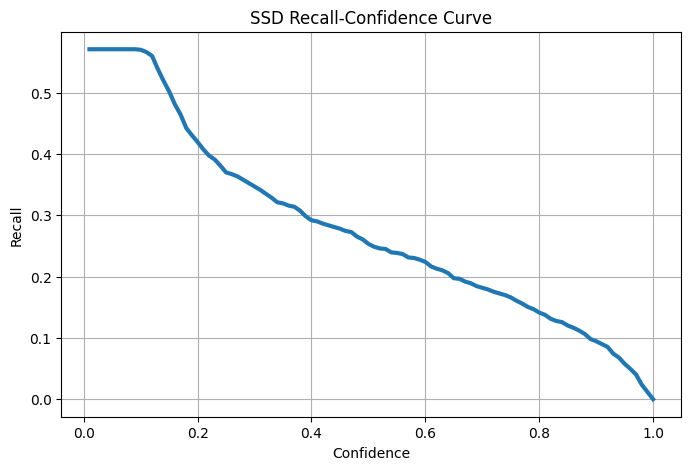

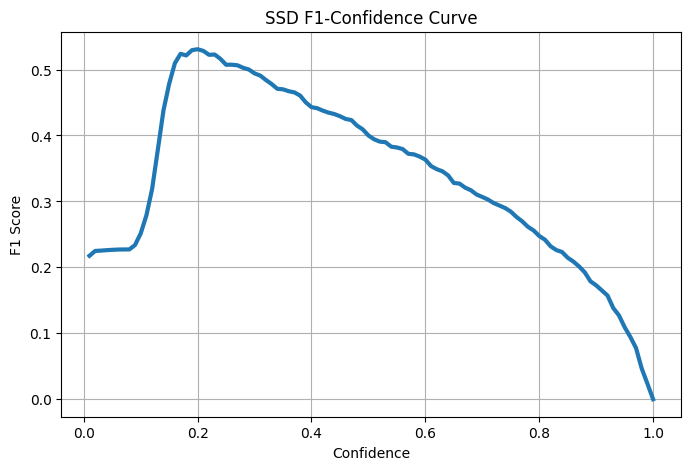

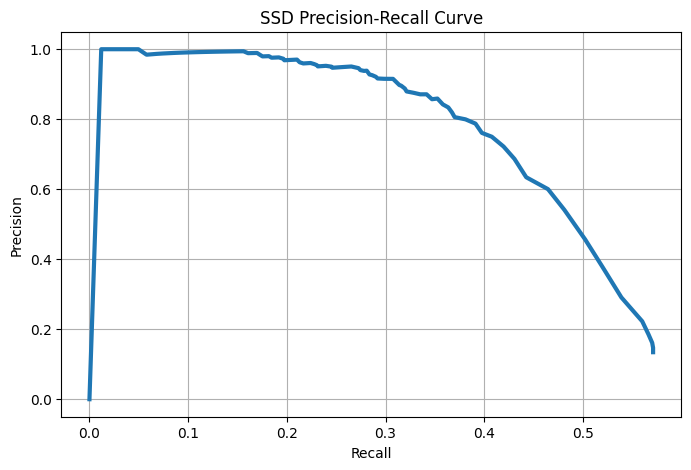

SSD Evaluation Completed!
Images Evaluated: 30
Best Precision: 72.20%
Best Recall: 41.97%
Best F1 Score: 53.08%
Confidence at Best F1: 0.20


In [33]:
import torch
import matplotlib.pyplot as plt
from torchvision.ops import box_iou
import numpy as np

model_ssd.eval()

all_scores = []
all_tp = []
all_fp = []
total_gt = 0

MAX_IMAGES = 30
image_count = 0
IOU_THRESHOLD = 0.5

with torch.no_grad():

    for images, targets in dataloader:

        for image, target in zip(images, targets):

            if image_count >= MAX_IMAGES:
                break

            image = image.to(device)

            prediction = model_ssd([image])[0]

            pred_boxes = prediction["boxes"].cpu()
            pred_scores = prediction["scores"].cpu()

            gt_boxes = target["boxes"].cpu()

            total_gt += len(gt_boxes)

            # Sort predictions by confidence
            order = torch.argsort(pred_scores, descending=True)

            pred_boxes = pred_boxes[order]
            pred_scores = pred_scores[order]

            matched_gt = set()

            for box, score in zip(pred_boxes, pred_scores):

                # Ignore very low confidence detections
                if score < 0.01:
                    continue

                if len(gt_boxes) == 0:
                    all_scores.append(float(score))
                    all_tp.append(0)
                    all_fp.append(1)
                    continue

                ious = box_iou(box.unsqueeze(0), gt_boxes)[0]

                best_iou, best_idx = torch.max(ious, dim=0)

                all_scores.append(float(score))

                if best_iou >= IOU_THRESHOLD and int(best_idx) not in matched_gt:
                    all_tp.append(1)
                    all_fp.append(0)
                    matched_gt.add(int(best_idx))
                else:
                    all_tp.append(0)
                    all_fp.append(1)

            image_count += 1

        if image_count >= MAX_IMAGES:
            break


# Convert to arrays
scores = np.array(all_scores)
tp = np.array(all_tp)
fp = np.array(all_fp)

# Confidence thresholds
thresholds = np.linspace(0.01, 1.0, 100)

precision = []
recall = []
f1 = []

for threshold in thresholds:

    selected = scores >= threshold

    TP = tp[selected].sum()
    FP = fp[selected].sum()

    FN = total_gt - TP

    p = TP / (TP + FP) if (TP + FP) > 0 else 0
    r = TP / (TP + FN) if (TP + FN) > 0 else 0

    f = (2 * p * r / (p + r)) if (p + r) > 0 else 0

    precision.append(p)
    recall.append(r)
    f1.append(f)


# =========================
# 1. Precision-Confidence
# =========================

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision, linewidth=3)
plt.title("SSD Precision-Confidence Curve")
plt.xlabel("Confidence")
plt.ylabel("Precision")
plt.grid()
plt.show()


# =========================
# 2. Recall-Confidence
# =========================

plt.figure(figsize=(8, 5))
plt.plot(thresholds, recall, linewidth=3)
plt.title("SSD Recall-Confidence Curve")
plt.xlabel("Confidence")
plt.ylabel("Recall")
plt.grid()
plt.show()


# =========================
# 3. F1-Confidence
# =========================

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1, linewidth=3)
plt.title("SSD F1-Confidence Curve")
plt.xlabel("Confidence")
plt.ylabel("F1 Score")
plt.grid()
plt.show()


# =========================
# 4. Precision-Recall Curve
# =========================

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=3)
plt.title("SSD Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()


# =========================
# Final values
# =========================

best_index = np.argmax(f1)

print("SSD Evaluation Completed!")
print(f"Images Evaluated: {image_count}")
print(f"Best Precision: {precision[best_index] * 100:.2f}%")
print(f"Best Recall: {recall[best_index] * 100:.2f}%")
print(f"Best F1 Score: {f1[best_index] * 100:.2f}%")
print(f"Confidence at Best F1: {thresholds[best_index]:.2f}")

In [34]:
from pathlib import Path
import matplotlib.pyplot as plt

ssd_graph_dir = Path("ssd_results") / "graphs"
ssd_graph_dir.mkdir(parents=True, exist_ok=True)

plot_definitions = [
    (thresholds, precision, "SSD Precision-Confidence Curve", "Confidence", "Precision", "ssd_precision_confidence.png"),
    (thresholds, recall, "SSD Recall-Confidence Curve", "Confidence", "Recall", "ssd_recall_confidence.png"),
    (thresholds, f1, "SSD F1-Confidence Curve", "Confidence", "F1 Score", "ssd_f1_confidence.png"),
    (recall, precision, "SSD Precision-Recall Curve", "Recall", "Precision", "ssd_precision_recall.png"),
]

for x_values, y_values, title, x_label, y_label, filename in plot_definitions:
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, linewidth=3)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid()
    plt.tight_layout()
    plt.savefig(ssd_graph_dir / filename)
    plt.close()

print("SSD graphs exported:", ssd_graph_dir)

SSD graphs exported: ssd_results\graphs
